# Run an initial LLOWFSC calibration assuming the DM flat command is applied and we are well aligned to the vortex mask. 

In [ ]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
from datetime import timezone 
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, coro_utils
from lina import llowfsc, rt_utils, dm

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

data_path = Path(f'../data/{today}-llowfsc')
utils.make_dir(data_path)


INFO:numexpr.utils:NumExpr defaulting to 12 threads.
/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Directory '../data/20260605-llowfsc' already exists.


INFO:purepyindi2.transports:Connected to localhost:7624


Exception in thread IndiTcpClientConnection-receiver:
Traceback (most recent call last):
  File "/opt/conda/envs/km310gpu/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/opt/conda/envs/km310gpu/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/opt/conda/envs/km310gpu/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/MagAOX-scoob-resurrector/source/purepyindi2/purepyindi2/transports.py", line 118, in _handle_inbound
    self._parser.parse(data)
  File "/opt/MagAOX-scoob-resurrector/source/purepyindi2/purepyindi2/parser.py", line 59, in parse
    self.parser.Parse(data)
  File "/home/conda/feedstock_root/build_artifacts/python-split_1744322439874/work/Modules/pyexpat.c", line 475, in EndElement
  File "/opt/MagAOX-scoob-resurrector/source/purepyindi2/purepyindi2/parser.py", line 174, in end_xml_element_handler
    element.set_fr

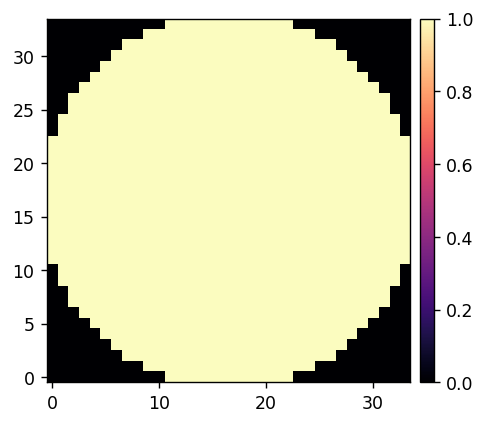

In [4]:
DM_STREAMS = []
for i in range(1,11):
    DM_STREAMS.append(ImageStream(f'dm00disp{i:02}'))

Nact = DM_STREAMS[0].shape[0]
dm_mask = dm.create_mask(Nact=Nact, return_np=1)
utils.imshow(
    [dm_mask]
)

# Test injecting some disturbances.

1e-08
Generated frequency vector with sampling of 2.78e-04Hz and maximum frequency of 2.50e+02Hz.
Generating time series for WFE mode 1.
	RMS of generated knee PSD: 1.000e-08
	RMS of generated time series: 1.002e-08 RMS
Generating time series for WFE mode 2.
	RMS of generated knee PSD: 1.000e-08
	RMS of generated time series: 1.002e-08 RMS
Generating time series for WFE mode 3.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.004e-09 RMS
Generating time series for WFE mode 4.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.004e-09 RMS
Generating time series for WFE mode 5.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.004e-09 RMS
Generating time series for WFE mode 6.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.004e-09 RMS
Generating time series for WFE mode 7.
	RMS of generated knee PSD: 1.000e-09
	RMS of generated time series: 1.004e-09 RMS
Generating time series for WFE mode 8.
	RMS of g

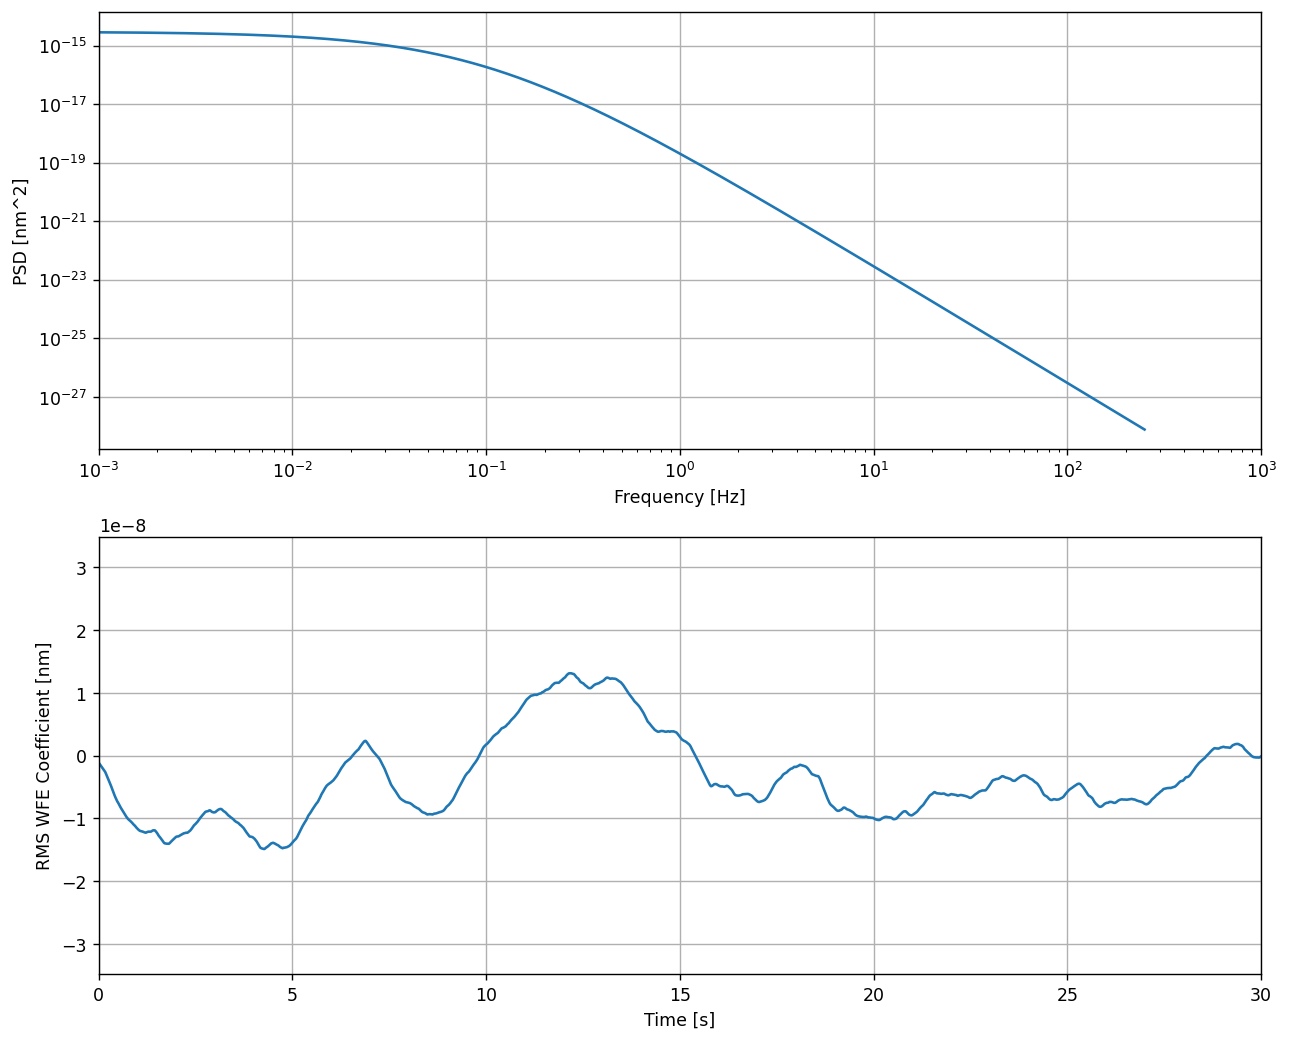

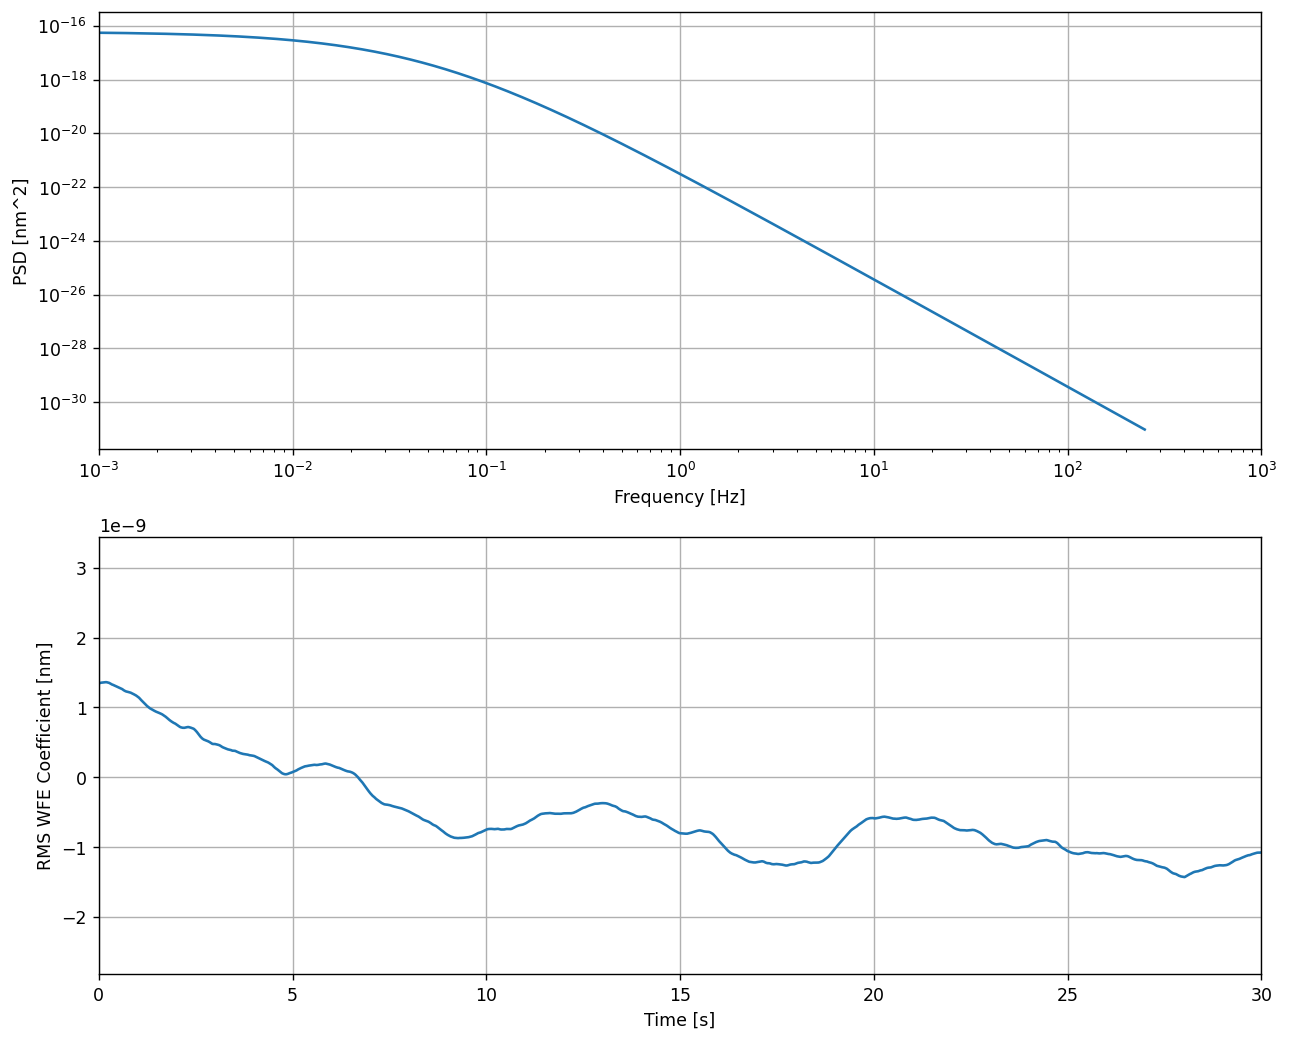

In [10]:
from lina import wfe
reload(wfe)

temp_sampling = 2e-3
tmax_for_psd = 3600

los_jitter_rms = 10e-9
los_jitter_fknee = 0.1
print(los_jitter_rms)

z3_z10_amp_rms = 1e-9
z3_z10_fknee = 0.05

wfe_modes_rms = np.array(2*[los_jitter_rms] + 8*[z3_z10_amp_rms])
f_knees = np.array(2*[los_jitter_fknee] + 8*[z3_z10_fknee])
psd_slope = 4

N_wfe_modes = len(wfe_modes_rms)
wfe_modes = utils.create_zernike_modes(dm_mask, nmodes=N_wfe_modes, remove_modes=1)

freqs, delf, times = wfe.generate_freqs(
    delt=temp_sampling, 
    tmax=tmax_for_psd, 
    verbose=True,
)

wfe_psds = xp.zeros((N_wfe_modes, len(freqs)))
wfe_time_series = xp.zeros((N_wfe_modes, len(times)))
seeds = 123 + np.linspace(0, N_wfe_modes-1, N_wfe_modes).astype(int)

for i in range(N_wfe_modes):
# for i in range(3):
    print(f'Generating time series for WFE mode {i+1}.')
    psd = wfe.roll_psd(
        freqs,
        wfe_modes_rms[i],
        f_knees[i],
        psd_slope,
        verbose=True, 
    )
    wfe_psds[i] = copy.copy(psd)

    time_series, times = wfe.generate_time_series(
        psd,
        freqs,
        seed=1234+i,
        # plot=True,
        verbose=True,
    )

    sign = 1 if xp.random.randn(1)>0 else -1
    time_series *= sign
    wfe_time_series[i] = copy.copy(time_series)

    if i==0 or i==2:
        fig, axs = plt.subplots(nrows=2, ncols=1, dpi=125, figsize=(12,10))

        np_freqs = ensure_np_array(freqs)
        np_psd = ensure_np_array(psd)
        np_times = ensure_np_array(times)
        np_time_series = ensure_np_array(time_series)

        series_ylims = 1.2*np.array([-np.max(np.abs(np_time_series)), np.max(np.abs(np_time_series))])

        axs[0].loglog(np_freqs, np_psd)
        axs[0].set_xlim(0.001, 1000)
        axs[0].set_ylabel('PSD [nm^2]')
        axs[0].set_xlabel('Frequency [Hz]')
        axs[0].grid()

        axs[1].plot(np_times, np_time_series)
        axs[1].set_xlim(0, 30)
        # axs[1].set_ylim(series_ylims)
        axs[1].set_ylabel('RMS WFE Coefficient [nm]')
        axs[1].set_xlabel('Time [s]')
        axs[1].grid()

np_wfe_time_series = ensure_np_array(wfe_time_series)

In [6]:
wfe_time_series.shape, wfe_time_series[:,0]

((10, 1800000),
 array([ 1.13464091e-08, -3.77191328e-09,  1.93970828e-09, -2.32666200e-10,
        -1.50096268e-09,  1.07949358e-10,  4.32033538e-10,  4.39831623e-10,
        -1.84873852e-09,  1.02032173e-09]))

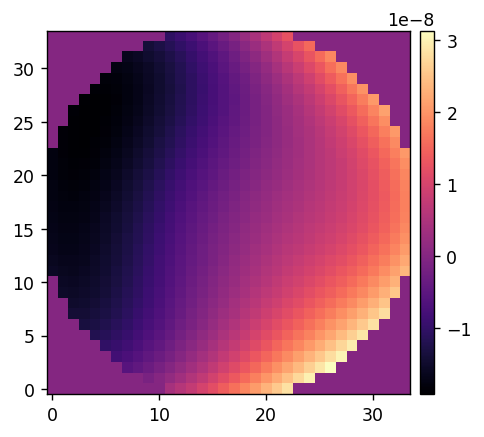

In [7]:
wfe_coeff = wfe_time_series[:,0]
utils.imshow(
    [xp.sum(wfe_coeff[:,None,None] * wfe_modes, axis=0)],
)

In [11]:
CYCLETIME = temp_sampling

try:
    print('Continuously updating OPD ...')
    
    t0 = time.perf_counter()  # Time ref point
    time_counter = 0.0

    i = 0
    while 1:
        if i==wfe_time_series.shape[1]-1: 
            i = 0
        wfe_coeff = wfe_time_series[:,i]
        wfe = ensure_np_array(1e6*xp.sum(wfe_coeff[:,None,None] * wfe_modes, axis=0))
        DM_STREAMS[3].write(wfe)
        i+=1
        # print([np_wfe_time_series[:, i]])
        
        now = time.perf_counter()
        elapsed_time = now - t0
        target_time = time_counter + CYCLETIME
        if elapsed_time < target_time:
            time.sleep(target_time - elapsed_time)

        time_counter += CYCLETIME
except KeyboardInterrupt:
    DM_STREAMS[3].write(np.zeros(DM_STREAMS[3].shape))
    print('OPD updates terminated.')

Continuously updating OPD ...
OPD updates terminated.
